# T1 diagnostic: AOM/PMT delay

Plots the wide-window capture from `t1_test.py diagnostic` (`run_delay_diagnostic()`) --
a single readout event captured from well before its trigger (t=0, the AWG marker edge at
the start of the 300ns RF burst that drives the AOM) to well after, so the actual
combined AOM-turn-on + acoustic-transit + PMT-response + cabling delay can be read
directly off the trace instead of guessed from datasheets. No live instrument connection
needed here -- everything comes from the saved `.npy`/metadata files.

This data reflects two fixes (see notes.md): (1) `RTB2004.run()` was querying the sample
rate before switching into `ACQuire:MEMory MANual` mode, giving the wrong rate for a
non-default `scale_s` -- metadata now reads `sample_rate_hz=312e6`, `t0_s=-4.9728e-6`,
matching the requested `DIAGNOSTIC_START_S=-5e-6` closely. (2) The normal sequence's two
identically-marked readout events made it ambiguous which pulse the scope was capturing --
`run_delay_diagnostic()` now uses `upload_diagnostic_sequence()` (no calibration stage, only
one readout per loop), confirmed by a now-uniform ~33.9us inter-trigger spacing in the
timetable. The resulting delay estimate (0.399us) matches the earlier ambiguous-sequence
measurement (0.389us) almost exactly, as expected -- the delay is a property of the
AOM/PMT/cabling chain, not of which readout instance produced it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from rtb2004 import make_t_from_metadata

DATA_DIR = "D:/t1"
NAME = "diagnostic_delay"

READOUT_PULSE_S = 300e-9  # the readout RF burst's duration, starting at t=0

In [2]:
waveform = np.load(f"{DATA_DIR}/{NAME}.npy")
t_s = make_t_from_metadata(f"{DATA_DIR}/{NAME}_metadata.txt")
t_us = t_s * 1e6

print(f"waveform shape: {waveform.shape} "
      f"({waveform.shape[0]} segments, {waveform.shape[1]} samples/segment)")
print(f"window: {t_us[0]:+.3f} us to {t_us[-1]:+.3f} us relative to the readout trigger "
      f"({t_us[-1] - t_us[0]:.3f} us wide)")

mean_waveform = waveform.mean(axis=0)
std_waveform = waveform.std(axis=0)
n_segments = waveform.shape[0]
sem_waveform = std_waveform / np.sqrt(n_segments)

waveform shape: (100, 10000) (100 segments, 10000 samples/segment)
window: -4.973 us to +27.075 us relative to the readout trigger (32.048 us wide)


## Estimate the delay

Baseline = the averaged trace's own point-to-point jitter *before* the trigger (t < 0) --
using the trace's own scatter as the noise reference, rather than the raw per-segment std,
since averaging `n_segments` segments already reduces jitter roughly like `1/sqrt(N)` (see
the earlier SEM-vs-raw-std discussion in `analyze_data.ipynb`).

**This PMT's fluorescence signal is NEGATIVE-going** (more light = more negative voltage) --
confirmed by comparing the signal vs. calibration readouts in the sweep-point check below.
Delay estimate = first point at/after t=0 where the averaged trace drops BELOW baseline by
more than `THRESHOLD_SIGMA` times the baseline jitter (a signed, negative-going threshold,
not `abs(deviation)`) -- an earlier version used `abs(deviation)`, which picked up a
positive-going transient instead (most likely the AOM still ramping up to full diffraction
efficiency, not real fluorescence -- see notes.md).

In [3]:
THRESHOLD_SIGMA = 5.0

baseline_mask = t_s < 0
if not np.any(baseline_mask):
    raise ValueError(
        "no samples before t=0 in this capture -- widen DIAGNOSTIC_START_S "
        "(more negative) in t1_test.py and re-run the diagnostic"
    )

baseline_mean = mean_waveform[baseline_mask].mean()
baseline_jitter = mean_waveform[baseline_mask].std()

after_trigger = np.where(t_s >= 0)[0]
deviation = mean_waveform[after_trigger] - baseline_mean
crossing = after_trigger[deviation < -THRESHOLD_SIGMA * baseline_jitter]  # negative-going only

if len(crossing) == 0:
    print(f"No {THRESHOLD_SIGMA}-sigma NEGATIVE-going departure from baseline found after "
          f"t=0 -- either the delay is longer than this window, the signal is weaker than "
          f"{THRESHOLD_SIGMA} sigma below baseline jitter, or something else is wrong. "
          f"Look at the plot below directly.")
    estimated_delay_s = None
else:
    estimated_delay_s = t_s[crossing[0]]
    print(f"baseline: {baseline_mean:.5f} V, jitter (1 sigma): {baseline_jitter:.6f} V")
    print(f"estimated AOM/PMT delay (true fluorescence onset): "
          f"{estimated_delay_s*1e6:.3f} us after the readout trigger")

baseline: -0.01016 V, jitter (1 sigma): 0.001151 V
estimated AOM/PMT delay: 0.399 us after the readout trigger


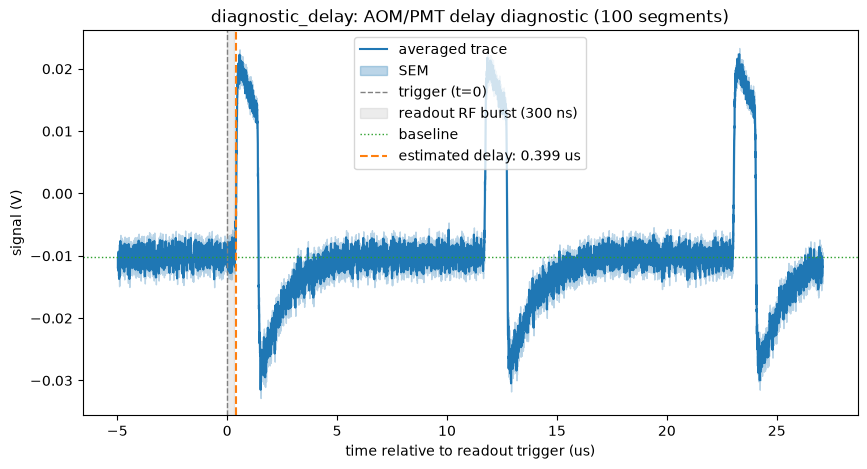

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(t_us, mean_waveform, color="C0", label="averaged trace")
ax.fill_between(t_us, mean_waveform - sem_waveform, mean_waveform + sem_waveform,
                 color="C0", alpha=0.3, label="SEM")

ax.axvline(0, color="gray", ls="--", lw=1, label="trigger (t=0)")
ax.axvspan(0, READOUT_PULSE_S * 1e6, color="gray", alpha=0.15,
            label=f"readout RF burst ({READOUT_PULSE_S*1e9:.0f} ns)")
ax.axhline(baseline_mean, color="C2", ls=":", lw=1, label="baseline")

if estimated_delay_s is not None:
    ax.axvline(estimated_delay_s * 1e6, color="C1", ls="--",
                label=f"estimated delay: {estimated_delay_s*1e6:.3f} us")

ax.set_xlabel("time relative to readout trigger (us)")
ax.set_ylabel("signal (V)")
ax.set_title(f"{NAME}: AOM/PMT delay diagnostic ({n_segments} segments)")
ax.legend()
plt.show()

## Sweep point check: `1us_calib`

First real point from the 5000-segment `python t1_test.py` sweep. Each file's segments
are an interleaved mix of the dark-time-SIGNAL readout and the fresh-polarization
CALIBRATION readout (both readouts share the same scope marker -- see notes.md) --
averaging them together would blend two physically different measurements, so they're
separated first using the sequence's fixed two-gap timetable pattern (short gap =
signal->calibration within one loop, long gap = calibration->next loop's signal;
confirmed clean/alternating in the earlier timetable checks), not any assumption about
which one the scope happened to trigger on first.

As established above, this PMT's fluorescence is NEGATIVE-going -- "peak fluorescence"
is the MINIMUM voltage, and "onset" is a negative-going threshold crossing after t=0, not
the maximum/absolute-deviation used in an earlier version (which was picking up a
positive-going AOM-ramp-up transient, not real fluorescence).

In [2]:
def classify_signal_vs_calibration(timetable_s):
    """
    Boolean array (len = num segments), True where that segment is the dark-time
    SIGNAL readout, False where it's the fresh-polarization CALIBRATION readout --
    inferred purely from the sequence's fixed two-gap pattern (see markdown above).
    """
    gaps_us = np.diff(timetable_s) * 1e6
    threshold_us = (gaps_us.min() + gaps_us.max()) / 2
    is_short = gaps_us < threshold_us  # short gap: this segment is signal, next is calibration

    n = len(timetable_s)
    signal_mask = np.empty(n, dtype=bool)
    signal_mask[0] = is_short[0]
    for i in range(1, n):
        signal_mask[i] = not signal_mask[i - 1]

    # Sanity check: the alternation-from-first-gap result should agree with the
    # direct per-gap classification everywhere, or the pattern isn't as clean as
    # assumed (e.g. a missed/extra trigger) and this split shouldn't be trusted.
    direct_from_own_gap = is_short  # segment i (for i < n-1) is signal iff gaps_us[i] is short
    mismatches = np.sum(signal_mask[:-1] != direct_from_own_gap)
    if mismatches:
        print(f"WARNING: {mismatches} of {n-1} segments disagree between the "
              f"alternation and direct gap classification -- the signal/calibration "
              f"split below may not be reliable for this file")
    else:
        print(f"gap pattern is a clean alternation -- signal/calibration split is reliable")

    return signal_mask

In [3]:
SWEEP_NAME = "1us_calib"

sweep_waveform = np.load(f"{DATA_DIR}/{SWEEP_NAME}.npy")
sweep_t_s = make_t_from_metadata(f"{DATA_DIR}/{SWEEP_NAME}_metadata.txt")
sweep_timetable_s = np.load(f"{DATA_DIR}/{SWEEP_NAME}_timetable.npy")
sweep_t_us = sweep_t_s * 1e6

print(f"waveform shape: {sweep_waveform.shape} "
      f"({sweep_waveform.shape[0]} segments, {sweep_waveform.shape[1]} samples/segment)")
print(f"window: {sweep_t_us[0]:+.3f} us to {sweep_t_us[-1]:+.3f} us "
      f"({sweep_t_us[-1] - sweep_t_us[0]:.3f} us wide)")

signal_mask = classify_signal_vs_calibration(sweep_timetable_s)
print(f"{signal_mask.sum()} signal segments, {(~signal_mask).sum()} calibration segments")

signal_waveform = sweep_waveform[signal_mask]
calib_waveform = sweep_waveform[~signal_mask]

signal_mean = signal_waveform.mean(axis=0)
signal_sem = signal_waveform.std(axis=0) / np.sqrt(len(signal_waveform))
calib_mean = calib_waveform.mean(axis=0)
calib_sem = calib_waveform.std(axis=0) / np.sqrt(len(calib_waveform))

sweep_baseline_mask = sweep_t_s < 0
signal_baseline_mean = signal_mean[sweep_baseline_mask].mean()
signal_baseline_jitter = signal_mean[sweep_baseline_mask].std()
calib_baseline_mean = calib_mean[sweep_baseline_mask].mean()
calib_baseline_jitter = calib_mean[sweep_baseline_mask].std()


def find_fluorescence_onset(t_s, mean_trace, baseline_mean, baseline_jitter,
                            threshold_sigma=THRESHOLD_SIGMA):
    """First negative-going THRESHOLD_SIGMA crossing after t=0, or None."""
    after = np.where(t_s >= 0)[0]
    deviation = mean_trace[after] - baseline_mean
    crossing = after[deviation < -threshold_sigma * baseline_jitter]
    return t_s[crossing[0]] if len(crossing) else None


signal_onset_s = find_fluorescence_onset(sweep_t_s, signal_mean, signal_baseline_mean,
                                          signal_baseline_jitter)
calib_onset_s = find_fluorescence_onset(sweep_t_s, calib_mean, calib_baseline_mean,
                                         calib_baseline_jitter)

signal_peak_idx = np.argmin(signal_mean)
calib_peak_idx = np.argmin(calib_mean)

print(f"signal: baseline {signal_baseline_mean:.5f} V, peak (minimum) "
      f"{signal_mean[signal_peak_idx]:.5f} V at t={sweep_t_us[signal_peak_idx]:+.3f} us, "
      f"onset "
      + (f"{signal_onset_s*1e6:+.3f} us" if signal_onset_s is not None else "NOT FOUND"))
print(f"calibration: baseline {calib_baseline_mean:.5f} V, peak (minimum) "
      f"{calib_mean[calib_peak_idx]:.5f} V at t={sweep_t_us[calib_peak_idx]:+.3f} us, "
      f"onset "
      + (f"{calib_onset_s*1e6:+.3f} us" if calib_onset_s is not None else "NOT FOUND"))

waveform shape: (5000, 10000) (5000 segments, 10000 samples/segment)
window: -0.500 us to +3.500 us (4.000 us wide)
gap pattern is a clean alternation -- signal/calibration split is reliable
2500 signal segments, 2500 calibration segments


signal: baseline -0.01231 V, peak (minimum) -0.03071 V at t=+1.555 us, onset +1.418 us
calibration: baseline -0.01236 V, peak (minimum) -0.01407 V at t=+2.801 us, onset NOT FOUND


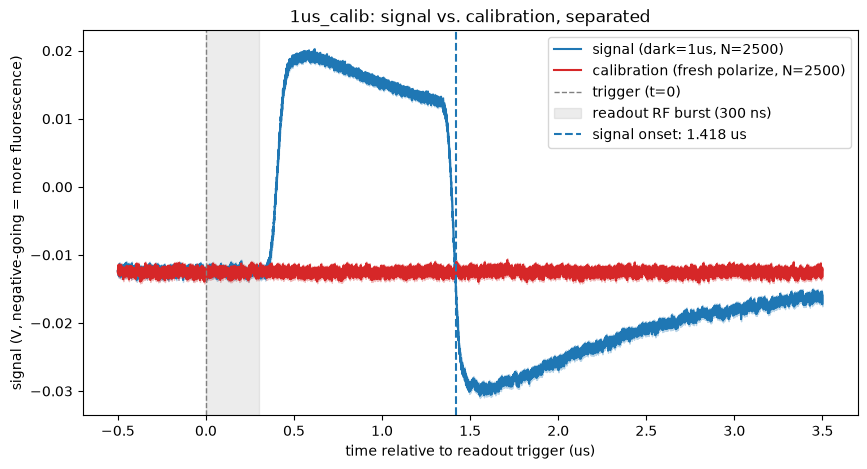

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(sweep_t_us, signal_mean, color="C0", label=f"signal (dark=1us, N={signal_mask.sum()})")
ax.fill_between(sweep_t_us, signal_mean - signal_sem, signal_mean + signal_sem, color="C0", alpha=0.3)

ax.plot(sweep_t_us, calib_mean, color="C3", label=f"calibration (fresh polarize, N={(~signal_mask).sum()})")
ax.fill_between(sweep_t_us, calib_mean - calib_sem, calib_mean + calib_sem, color="C3", alpha=0.3)

ax.axvline(0, color="gray", ls="--", lw=1, label="trigger (t=0)")
ax.axvspan(0, READOUT_PULSE_S * 1e6, color="gray", alpha=0.15,
            label=f"readout RF burst ({READOUT_PULSE_S*1e9:.0f} ns)")

if signal_onset_s is not None:
    ax.axvline(signal_onset_s * 1e6, color="C0", ls="--",
                label=f"signal onset: {signal_onset_s*1e6:.3f} us")
if calib_onset_s is not None:
    ax.axvline(calib_onset_s * 1e6, color="C3", ls="--",
                label=f"calibration onset: {calib_onset_s*1e6:.3f} us")

ax.set_xlabel("time relative to readout trigger (us)")
ax.set_ylabel("signal (V, negative-going = more fluorescence)")
ax.set_title(f"{SWEEP_NAME}: signal vs. calibration, separated")
ax.legend()
plt.show()

## T1 curve: signal fluorescence vs. dark time

Auto-discovers every completed sweep point in `D:/t1`, in EITHER format: new-style
`<N>us.npy` (single readout per segment, no calibration stage -- see notes.md/the
conversation this was decided in) used directly, or old-style `<N>us_calib.npy`
(interleaved signal+calibration, from before that fix) filtered down to just the
signal-classified segments via `classify_signal_vs_calibration()`. If both exist for the
same dark time, the new-style file wins. Plotting peak fluorescence vs. dark time directly
gives the T1 decay curve -- no calibration/normalization needed.

In [3]:
import os
import re

def find_dark_time_files(data_dir):
    """
    (dark_time_us, name, needs_classification) for every sweep point file in
    data_dir, sorted by dark_time_us. needs_classification is True for old-style
    "<N>us_calib.npy" files (interleaved signal+calibration), False for new-style
    "<N>us.npy" files (single readout, use directly). If both exist for the same
    dark time, the new-style file wins.
    """
    new_pattern = re.compile(r"^(\d+)us\.npy$")
    old_pattern = re.compile(r"^(\d+)us_calib\.npy$")

    found = {}
    for fname in os.listdir(data_dir):
        m_old = old_pattern.match(fname)
        if m_old:
            dark_time_us = int(m_old.group(1))
            found.setdefault(dark_time_us, (fname[:-4], True))
    for fname in os.listdir(data_dir):
        m_new = new_pattern.match(fname)
        if m_new:
            dark_time_us = int(m_new.group(1))
            found[dark_time_us] = (fname[:-4], False)  # new-style always wins

    return sorted((dt, name, needs_cls) for dt, (name, needs_cls) in found.items())


def load_signal_trace(data_dir, name, needs_classification):
    """(t_s, signal_mean, signal_sem, n_signal) -- just the SIGNAL-classified segments
    for old-style files, or all segments (already single-readout) for new-style ones."""
    waveform = np.load(f"{data_dir}/{name}.npy")
    t_s = make_t_from_metadata(f"{data_dir}/{name}_metadata.txt")

    if needs_classification:
        timetable_s = np.load(f"{data_dir}/{name}_timetable.npy")
        mask = classify_signal_vs_calibration(timetable_s)
        waveform = waveform[mask]

    signal_mean = waveform.mean(axis=0)
    signal_sem = waveform.std(axis=0) / np.sqrt(len(waveform))
    return t_s, signal_mean, signal_sem, len(waveform)


dark_time_files = find_dark_time_files(DATA_DIR)
print(f"found {len(dark_time_files)} points: {[dt for dt, _, _ in dark_time_files]} us")

found 29 points: [1, 2, 3, 4, 5, 7, 9, 13, 17, 24, 33, 45, 62, 85, 117, 161, 221, 304, 418, 574, 788, 1083, 1487, 2043, 2807, 3857, 5298, 7279, 10000] us


1us: peak -0.03604 V at t=+1.547 us (N=100 signal segments)
2us: peak -0.04585 V at t=+1.614 us (N=100 signal segments)
3us: peak -0.04653 V at t=+1.561 us (N=100 signal segments)
4us: peak -0.05122 V at t=+1.616 us (N=100 signal segments)
5us: peak -0.04805 V at t=+1.626 us (N=100 signal segments)
7us: peak -0.04795 V at t=+1.607 us (N=100 signal segments)
9us: peak -0.04785 V at t=+1.611 us (N=100 signal segments)
13us: peak -0.04351 V at t=+1.569 us (N=100 signal segments)
17us: peak -0.04219 V at t=+1.752 us (N=100 signal segments)
24us: peak -0.03750 V at t=+1.472 us (N=100 signal segments)
33us: peak -0.03369 V at t=+1.561 us (N=100 signal segments)
45us: peak -0.03232 V at t=+1.468 us (N=100 signal segments)
62us: peak -0.02871 V at t=+1.474 us (N=100 signal segments)


85us: peak -0.03125 V at t=+1.548 us (N=100 signal segments)
117us: peak -0.02959 V at t=+1.691 us (N=100 signal segments)
161us: peak -0.03193 V at t=+1.600 us (N=100 signal segments)
221us: peak -0.03228 V at t=+1.577 us (N=100 signal segments)


304us: peak -0.03271 V at t=+1.584 us (N=100 signal segments)
418us: peak -0.03164 V at t=+1.476 us (N=100 signal segments)
574us: peak -0.03096 V at t=+1.787 us (N=100 signal segments)
788us: peak -0.03276 V at t=+1.562 us (N=100 signal segments)
1083us: peak -0.03687 V at t=+1.584 us (N=100 signal segments)
1487us: peak -0.03379 V at t=+1.603 us (N=100 signal segments)
2043us: peak -0.03179 V at t=+1.700 us (N=100 signal segments)
2807us: peak -0.03262 V at t=+1.584 us (N=100 signal segments)
3857us: peak -0.02891 V at t=+1.670 us (N=100 signal segments)
5298us: peak -0.02969 V at t=+1.566 us (N=100 signal segments)
7279us: peak -0.03096 V at t=+1.515 us (N=100 signal segments)
10000us: peak -0.03330 V at t=+1.638 us (N=100 signal segments)


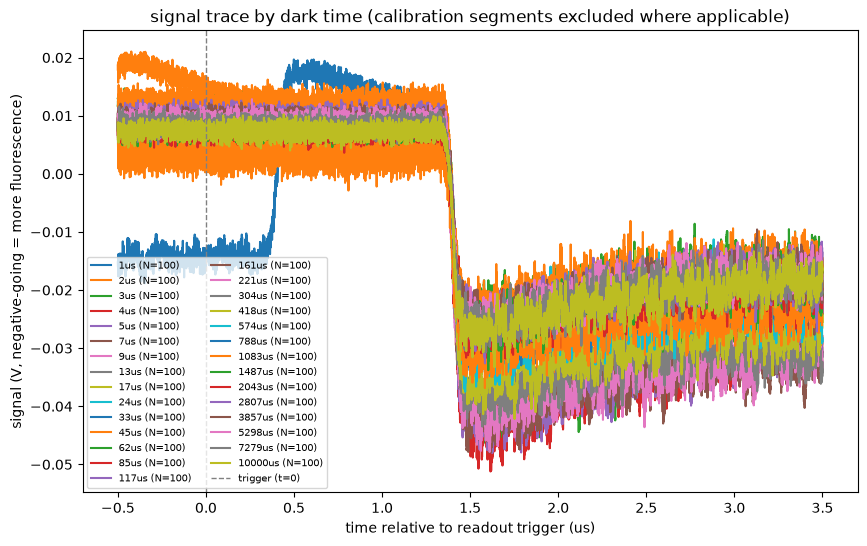

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

peak_dark_times_us = []
peak_values = []
peak_errs = []

for dark_time_us, name, needs_classification in dark_time_files:
    t_s, signal_mean, signal_sem, n_signal = load_signal_trace(DATA_DIR, name, needs_classification)
    t_us = t_s * 1e6
    ax.plot(t_us, signal_mean, label=f"{dark_time_us}us (N={n_signal})")

    peak_idx = np.argmin(signal_mean)
    peak_dark_times_us.append(dark_time_us)
    peak_values.append(signal_mean[peak_idx])
    peak_errs.append(signal_sem[peak_idx])
    print(f"{dark_time_us}us: peak {signal_mean[peak_idx]:.5f} V at t={t_us[peak_idx]:+.3f} us "
          f"(N={n_signal} signal segments)")

ax.axvline(0, color="gray", ls="--", lw=1, label="trigger (t=0)")
ax.set_xlabel("time relative to readout trigger (us)")
ax.set_ylabel("signal (V, negative-going = more fluorescence)")
ax.set_title("signal trace by dark time (calibration segments excluded where applicable)")
ax.legend(fontsize=7, ncol=2)
plt.show()

## Falloff diagnostic: how fast does fluorescence decay after turn-off

`python t1_test.py falloff` (`run_falloff_diagnostic()`) -- captures a wide window
around the polarize->dark TRANSITION (t=0 = the AWG marker edge at the moment the RF
drive to the AOM stops), instead of the turn-on transition the earlier diagnostic looked
at. Answers a different question: a constant turn-ON delay doesn't limit how short a
meaningful dark time can be (it only says where to look for the signal) -- what actually
matters is how long the AOM takes to stop diffracting light once told to turn off. A dark
period shorter than that wouldn't actually be dark. Before t=0 the trace should sit at the
steady-state BRIGHT level (continuously illuminated by the preceding `polarize` segment);
after t=0 it should decay toward the DARK baseline -- how long that takes is the real
answer.

In [2]:
FALLOFF_NAME = "diagnostic_falloff"

falloff_waveform = np.load(f"{DATA_DIR}/{FALLOFF_NAME}.npy")
falloff_t_s = make_t_from_metadata(f"{DATA_DIR}/{FALLOFF_NAME}_metadata.txt")
falloff_t_us = falloff_t_s * 1e6

print(f"waveform shape: {falloff_waveform.shape} "
      f"({falloff_waveform.shape[0]} segments, {falloff_waveform.shape[1]} samples/segment)")
print(f"window: {falloff_t_us[0]:+.3f} us to {falloff_t_us[-1]:+.3f} us relative to the "
      f"turn-off transition ({falloff_t_us[-1] - falloff_t_us[0]:.3f} us wide)")

falloff_mean = falloff_waveform.mean(axis=0)
falloff_std = falloff_waveform.std(axis=0)
falloff_n = falloff_waveform.shape[0]
falloff_sem = falloff_std / np.sqrt(falloff_n)

waveform shape: (100, 10000) (100 segments, 10000 samples/segment)
window: -1.974 us to +30.074 us relative to the turn-off transition (32.048 us wide)


In [3]:
# Bright level: mean of samples before t=0 (still illuminated by the
# preceding "polarize" segment). Dark (settled) level: mean of the LAST
# 10% of the window, assumed to have fully decayed by then.
bright_mask = falloff_t_s < 0
tail_n = max(1, falloff_waveform.shape[1] // 10)

bright_level = falloff_mean[bright_mask].mean()
bright_jitter = falloff_mean[bright_mask].std()
dark_level = falloff_mean[-tail_n:].mean()
dark_jitter = falloff_mean[-tail_n:].std()

print(f"bright level (t<0): {bright_level:.5f} V +/- {bright_jitter:.6f} V")
print(f"dark (settled) level (last 10% of window): {dark_level:.5f} V +/- {dark_jitter:.6f} V")

# "Settled" = first point after t=0 where the trace gets within
# THRESHOLD_SIGMA * dark_jitter of the dark level and STAYS there
# (checked via the running max deviation from that point onward, so a
# single noisy sample landing close to baseline by chance doesn't count).
THRESHOLD_SIGMA_FALLOFF = 5.0
after = np.where(falloff_t_s >= 0)[0]
deviation_from_dark = np.abs(falloff_mean[after] - dark_level)
still_settled_from_here = np.maximum.accumulate(deviation_from_dark[::-1])[::-1]  # max deviation from this point to the end
settled_candidates = after[still_settled_from_here <= THRESHOLD_SIGMA_FALLOFF * dark_jitter]

if len(settled_candidates) == 0:
    print("Never settles within this window -- decay takes longer than "
          f"{falloff_t_us[-1]:.1f} us, or the window is too short to tell.")
    settled_s = None
else:
    settled_s = falloff_t_s[settled_candidates[0]]
    print(f"settles to within {THRESHOLD_SIGMA_FALLOFF} sigma of the dark level at "
          f"t={settled_s*1e6:+.3f} us after turn-off")

bright level (t<0): -0.02416 V +/- 0.002411 V
dark (settled) level (last 10% of window): 0.00846 V +/- 0.000824 V
settles to within 5.0 sigma of the dark level at t=+3.090 us after turn-off


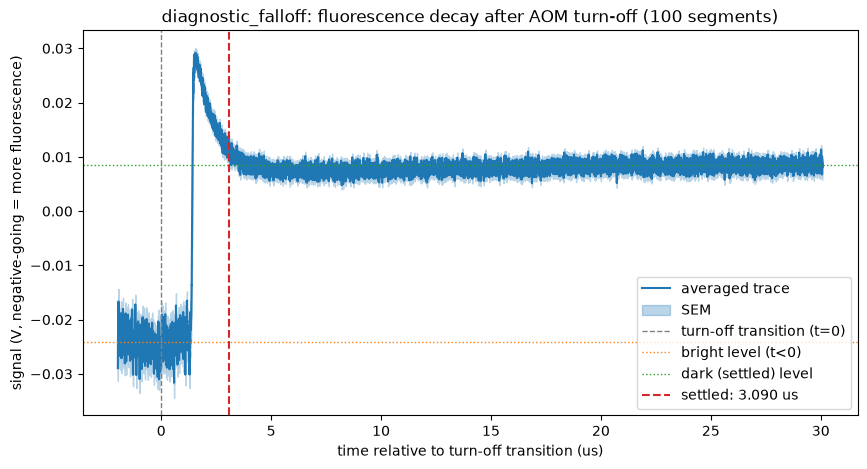

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(falloff_t_us, falloff_mean, color="C0", label="averaged trace")
ax.fill_between(falloff_t_us, falloff_mean - falloff_sem, falloff_mean + falloff_sem,
                 color="C0", alpha=0.3, label="SEM")

ax.axvline(0, color="gray", ls="--", lw=1, label="turn-off transition (t=0)")
ax.axhline(bright_level, color="C1", ls=":", lw=1, label="bright level (t<0)")
ax.axhline(dark_level, color="C2", ls=":", lw=1, label="dark (settled) level")

if settled_s is not None:
    ax.axvline(settled_s * 1e6, color="C3", ls="--",
                label=f"settled: {settled_s*1e6:.3f} us")

ax.set_xlabel("time relative to turn-off transition (us)")
ax.set_ylabel("signal (V, negative-going = more fluorescence)")
ax.set_title(f"{FALLOFF_NAME}: fluorescence decay after AOM turn-off ({falloff_n} segments)")
ax.legend()
plt.show()